In [19]:
import sys

sys.path.append("..")

In [20]:
import os
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np

from config import config
from data.data_loader import CREMADDataset

In [24]:
PLOT_DIR = "../../report/images"
os.makedirs(PLOT_DIR, exist_ok=True)

print(f"{config.dataset.emotions=}")
print(f"{config.dataset.n_speakers=}")

train_ds = CREMADDataset(split="train")
val_ds = CREMADDataset(split="val")
test_ds = CREMADDataset(split="test")

splits = {
    "Train": train_ds,
    "Validation": val_ds,
    "Test": test_ds,
}

for name, ds in splits.items():
    print(name, len(ds))

config.dataset.emotions=['NEU', 'HAP', 'ANG', 'SAD']
config.dataset.n_speakers=20


Loading weights: 100%|██████████| 211/211 [00:00<00:00, 68753.74it/s]


Train 864
Validation 108
Test 107


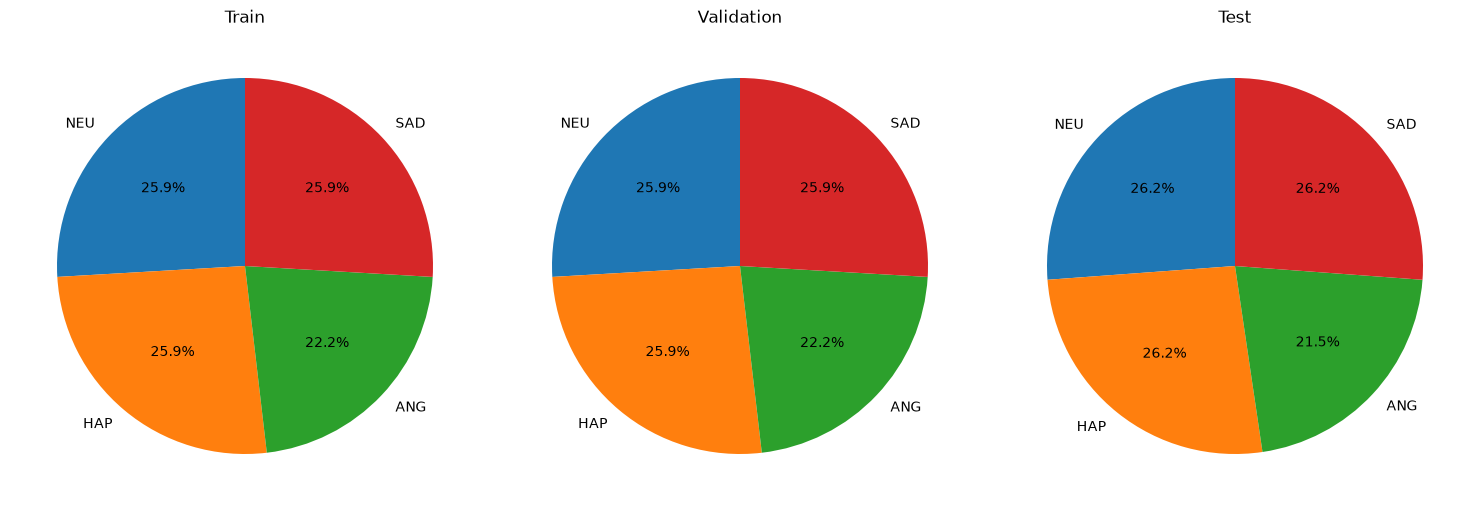

In [26]:
def count_dataset(ds, emotions):
    emotion_counts = Counter()
    actor_counts = Counter()
    for path, label in ds.samples:
        emotion_counts[emotions[label]] += 1
        actor_id = int(os.path.basename(path).split("_")[0])
        actor_counts[actor_id] += 1
    return emotion_counts, actor_counts

emotions = config.dataset.emotions

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, (name, ds) in zip(axes, splits.items()):
    emotion_counts, _ = count_dataset(ds, emotions)
    values = [emotion_counts.get(e, 0) for e in emotions]
    ax.pie(values, labels=emotions, autopct="%1.1f%%", startangle=90)
    ax.set_title(name)
plt.tight_layout()
plt.savefig(
    os.path.join(PLOT_DIR, "emotion_distribution.png")
)
plt.show()

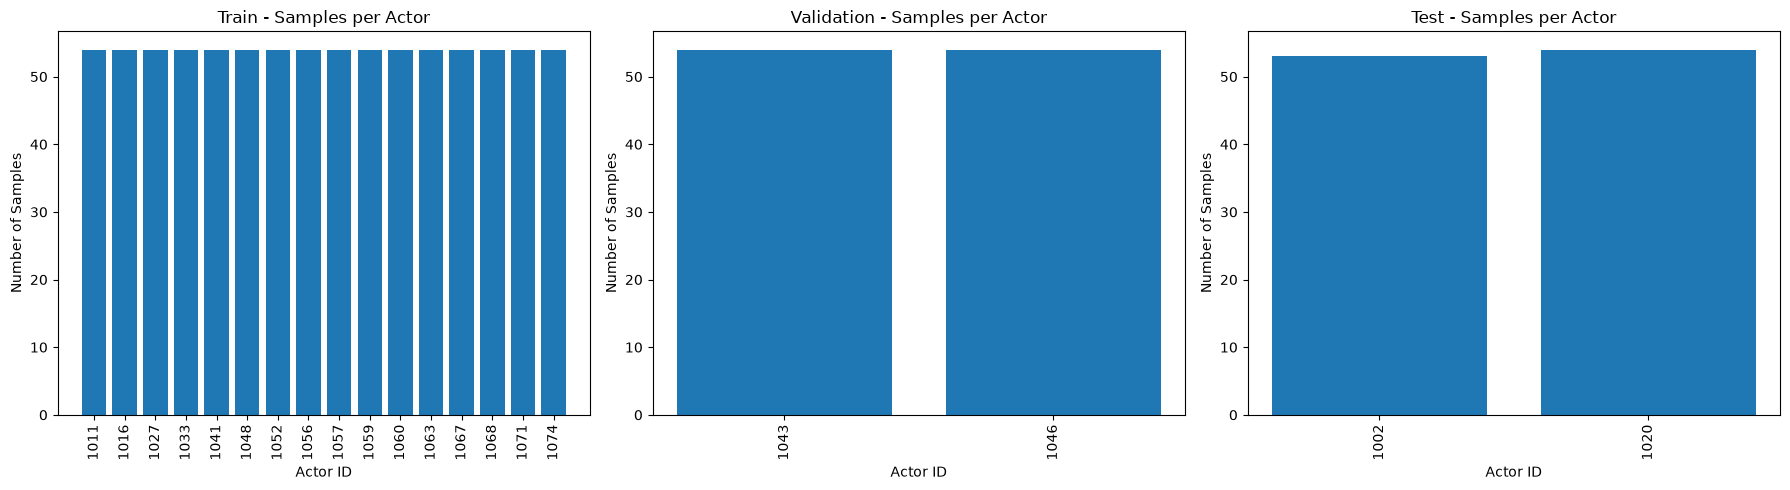

In [ ]:
split_actor_counts = {}
for name, ds in splits.items():
    _, actor_counts = count_dataset(ds, emotions)
    split_actor_counts[name] = actor_counts

unique_actors = sorted({aid for c in split_actor_counts.values() for aid in c})

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (name, actor_counts) in zip(axes, split_actor_counts.items()):
    actor_ids = sorted(actor_counts.keys())
    sample_counts = [actor_counts[a] for a in actor_ids]
    ax.bar([str(a) for a in actor_ids], sample_counts)
    ax.set_title(name)
    ax.set_xlabel("Actor ID")
    ax.set_ylabel("Number of Samples")
    ax.tick_params(axis="x", rotation=90)
plt.tight_layout()
plt.savefig(
    os.path.join(PLOT_DIR, "actor_distribution.png")
)
plt.show()